# 랜덤포레스트

## 아르바이트생 취업 선별

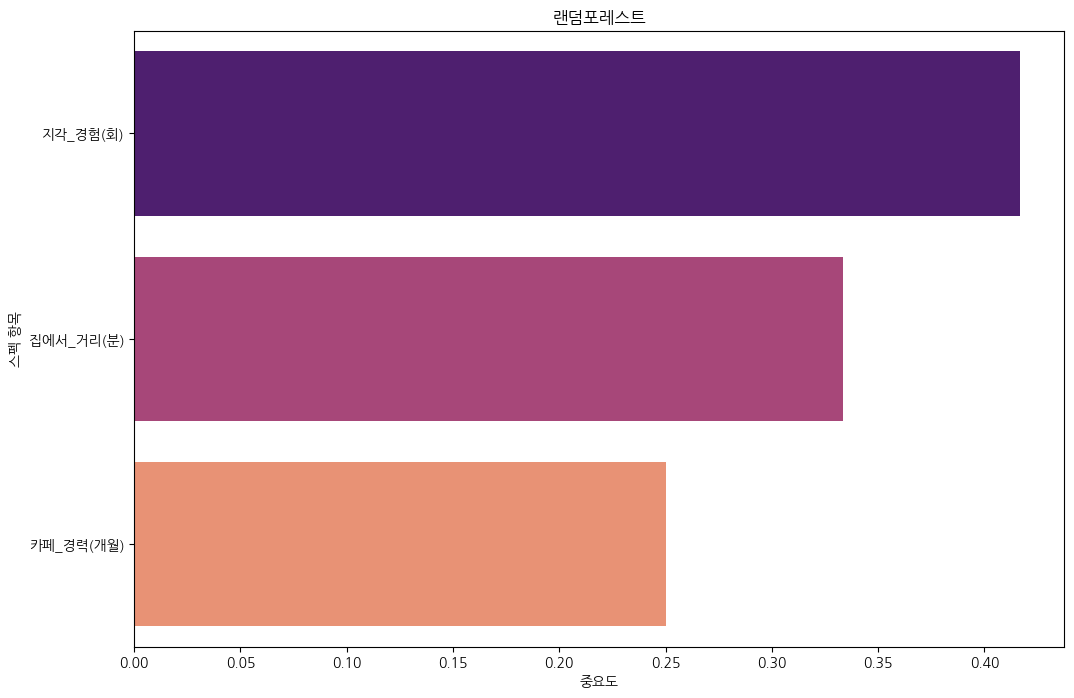

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

data3 = {
    '집에서_거리(분)': [10, 60, 15, 50, 5, 40, 20, 90, 30, 5],
    '카페_경력(개월)': [12, 0, 6, 2, 24, 0, 1, 0, 3, 18],
    '지각_경험(회)': [0, 3, 1, 5, 0, 2, 0, 10, 0, 1],
    '합격여부': ['합격', '불합격', '합격', '불합격', '합격', '불합격', '합격', '불합격', '합격', '합격']
}

df = pd.DataFrame(data3)
x = df[['집에서_거리(분)','카페_경력(개월)','지각_경험(회)']]
y = df['합격여부']

rf = RandomForestClassifier(n_estimators= 12 , random_state=42)
rf.fit(x, y)

importances = rf.feature_importances_
df_imp = pd.DataFrame({'스펙 항목': x.columns, '중요도': importances})
df_imp = df_imp.sort_values(by='중요도', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(x ='중요도', y='스펙 항목', hue='스펙 항목', data=df_imp, palette='magma')
plt.title('랜덤포레스트')
plt.show()


# 데이팅 어플

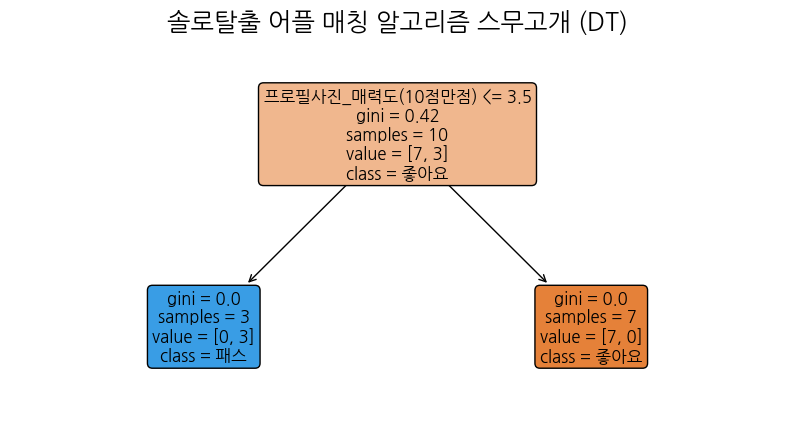

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 도파민 폭발 가상 데이터 생성 (데이팅 어플 유저 행동)
# (주의: 교육용으로 극단적으로 세팅된 가상 데이터입니다)
data = {
    '연락빈도(하루_몇번)': [1, 10, 20, 2, 5, 0, 15, 30, 2, 8],
    '티키타카_유머점수(10점만점)': [2, 8, 9, 3, 7, 1, 8, 9, 4, 6],
    '프로필사진_매력도(10점만점)': [3, 4, 8, 9, 5, 2, 9, 7, 8, 3],
    '매칭결과': ['패스', '좋아요', '좋아요', '좋아요', '좋아요', '패스', '좋아요', '좋아요', '좋아요', '패스']
}
df = pd.DataFrame(data)

# 독립변수(X)와 종속변수(y) 분리
X = df[['연락빈도(하루_몇번)', '티키타카_유머점수(10점만점)', '프로필사진_매력도(10점만점)']]
y = df['매칭결과']

# 2. 의사결정나무(DT) 모델 학습
dt_model = DecisionTreeClassifier(max_depth=2, random_state=42)
dt_model.fit(X, y)

# 3. 유저들의 "호감 심리 스무고개" 차트 생성
plt.figure(figsize=(10, 5))
plot_tree(dt_model, 
          feature_names=X.columns, 
          class_names=dt_model.classes_, 
          filled=True, rounded=True, fontsize=12)

plt.title("솔로탈출 어플 매칭 알고리즘 스무고개 (DT)", fontsize=18)
plt.show()

# 👨‍🏫 [교수님 설명 팁]
# "차트를 뽑아보니 가장 꼭대기에 뭐가 있나요? '티키타카 유머점수 <= 2.5' 혹은 '프로필 매력도 <= 4' 같은 게 떴을 겁니다.
# 이걸 보고 마케팅 팀장님께 이렇게 보고하는 겁니다. 
# '팀장님! 우리 앱 유저들은 연락을 하루 100번 해도 소용없습니다. 일단 프로필 매력도가 4점 이상을 넘기지 못하면 
# 밑에 트리 조건(연락/유머)은 타보지도 못하고 100% 무조건 [패스] 당합니다!' 
# 사람의 심리(인과관계)를 무 자르듯 팩트 폭행해 주는 게 바로 DT입니다."

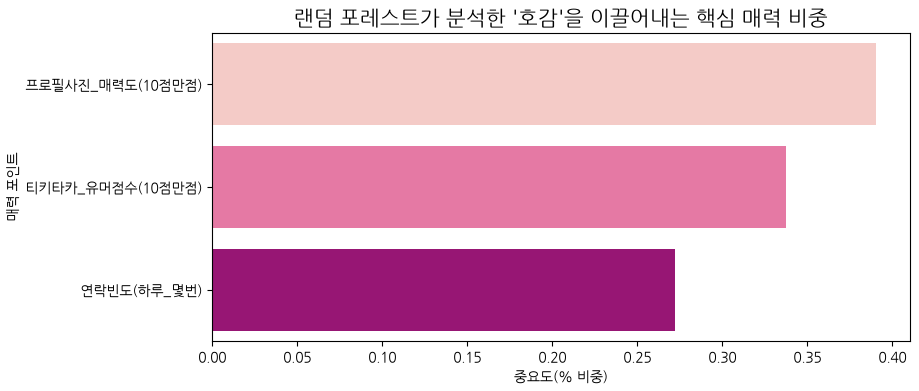